/tmp/ipython-input-3491754834.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Type", data=df, palette="Set2")


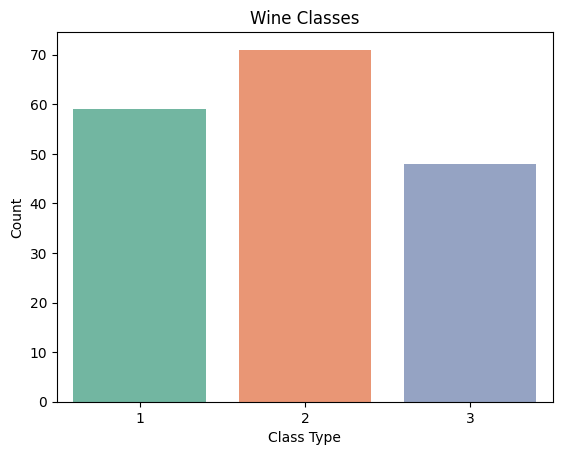

SVM Accuracy: 0.963
RF  Accuracy: 1.000

SVM Classification Report:
               precision    recall  f1-score   support

           1       0.95      1.00      0.97        18
           2       0.95      0.95      0.95        21
           3       1.00      0.93      0.97        15

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.96      0.96      0.96        54

RF Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        21
           3       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



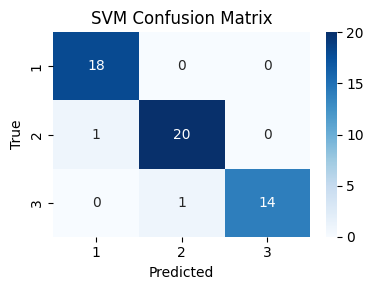

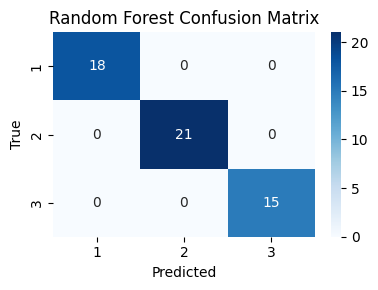

/tmp/ipython-input-3491754834.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_imp[idx_rf][:13], y=np.array(feature_names)[idx_rf][:13], palette="viridis")


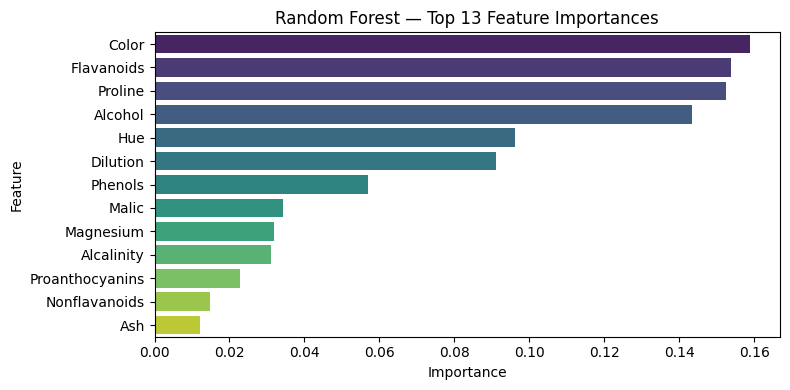

/tmp/ipython-input-3491754834.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=svm_imp[idx_svm][:13], y=np.array(feature_names)[idx_svm][:13], palette="magma")


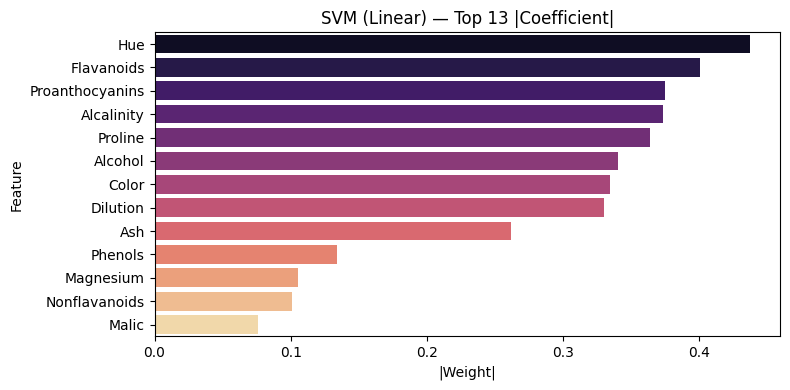

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline

# ==== Load dataset (CSV) ====
df = pd.read_csv("wine.csv")      # file must contain column name "Type"

# split X / y
X = df.drop("Type", axis=1).values
y = df["Type"].values

feature_names = df.drop("Type", axis=1).columns
target_names = sorted(df["Type"].unique().astype(str))


# ==== Class distribution ====
sns.countplot(x="Type", data=df, palette="Set2")
plt.title("Wine Classes"); plt.xlabel("Class Type"); plt.ylabel("Count")
plt.show()


# ==== Train / Test split (70/30) ====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)


# ==== SVM (linear kernel) ====
svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", random_state=42))
])
svm_clf.fit(X_train, y_train)
y_pred_svm = svm_clf.predict(X_test)


# ==== Random Forest ====
rf_clf = RandomForestClassifier(n_estimators=300, random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)


# ==== Metrics ====
print(f"SVM Accuracy: {accuracy_score(y_test, y_pred_svm):.3f}")
print(f"RF  Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")

print("\nSVM Classification Report:\n",
      classification_report(y_test, y_pred_svm, target_names=target_names))

print("RF Classification Report:\n",
      classification_report(y_test, y_pred_rf, target_names=target_names))


# ==== Confusion Matrix plot ====
def plot_cm(cm, title):
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=target_names, yticklabels=target_names)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

plot_cm(confusion_matrix(y_test, y_pred_svm), "SVM Confusion Matrix")
plot_cm(confusion_matrix(y_test, y_pred_rf), "Random Forest Confusion Matrix")


# ==== Feature Importance ====

# RF feature importance
rf_imp = rf_clf.feature_importances_
idx_rf = np.argsort(rf_imp)[::-1]
plt.figure(figsize=(8,4))
sns.barplot(x=rf_imp[idx_rf][:13], y=np.array(feature_names)[idx_rf][:13], palette="viridis")
plt.title("Random Forest — Top 13 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# SVM coefficients → mean(|coef|)
svm = svm_clf.named_steps["svm"]
svm_imp = np.mean(np.abs(svm.coef_), axis=0)
idx_svm = np.argsort(svm_imp)[::-1]
plt.figure(figsize=(8,4))
sns.barplot(x=svm_imp[idx_svm][:13], y=np.array(feature_names)[idx_svm][:13], palette="magma")
plt.title("SVM (Linear) — Top 13 |Coefficient|")
plt.xlabel("|Weight|")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



